In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fno_definitions import*
import torch

# Literature

1) FNO for differential equations
https://arxiv.org/abs/2010.08895

2) General introduction, complete
https://arxiv.org/abs/2512.01421v2, see NeuralOperator 2.0.0 library

# Minor stuff and trials

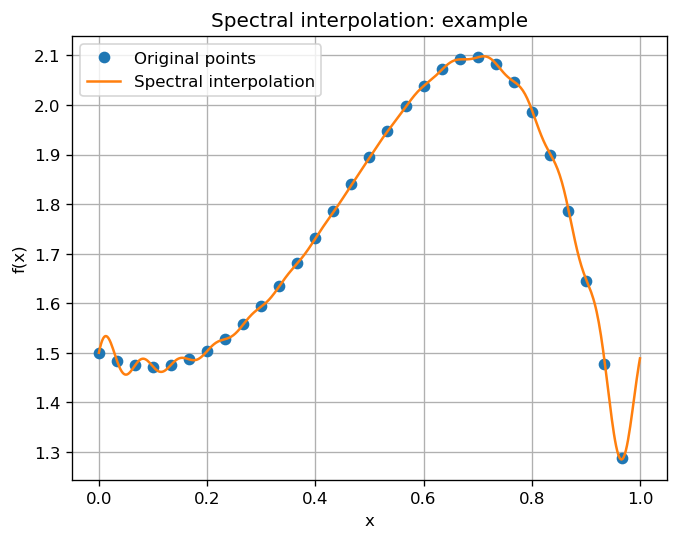

In [6]:
# test: spectral interpolation of 1d vector

def spectral_interpolation(signal: torch.tensor, M: int) -> torch.Tensor:

    """Gives the spectral interpolation of a 1d array on M points. Following 2), page 16"""
    N = len(signal) 
    fft_coeffs = torch.fft.fft(signal)
    pos_freqs = fft_coeffs[:N//2 + 1]
    neg_freqs = fft_coeffs[N//2 + 1:]

    fft_coeffs_padded = torch.cat([pos_freqs, torch.zeros(M - N), neg_freqs])

    return (torch.fft.ifft(fft_coeffs_padded).real)*M/N # the interpolated signal, scale by M/N to preserve energy


f = lambda x: torch.sin(3*x**2) + 0.5*torch.cos(torch.sqrt(x)) + 1.0 - x/3.

N = 30
xx = torch.linspace(0, 1, N+1)[:-1] # data x_n, n from 0 to N-1 

M_eval = 500

plt.figure(dpi = 120)
plt.title('Spectral interpolation: example')
plt.grid()
plt.xlabel('x')
plt.ylabel('f(х)')
plt.plot(xx, f(xx), 'o', label = 'Original points')
plt.plot(torch.linspace(0, 1, M_eval), spectral_interpolation(f(xx), M_eval), label = 'Spectral interpolation')
plt.legend()
plt.show()

# First FNO trial (with definition from `fno_definitions.py`)

In [2]:
# start with something reasonably small
fno_trial = FNO_v1(n_modes = [8,8], hidden_dimension = 24, lr = 0.001)

# note that compared to the way I set up the deepONets, here the X and Y (input and output) arrays are kept 2d and not flattened with .ravel().
# this is because I need to distinguish the two directions for the 2d fft to be applicable

# the solutions in the dataset are computed on the [-1, 1] 2d-square, on a 64x64 grid
fno_trial.fit_from_npz('data/dataset_for_fno.npz', 100)

Y std across samples: 0.04565034061670303
Y std across points:  0.02651088498532772


/Users/filippo/Desktop/neural_operators/fno_definitions.py:82: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [800, 64, 33, 24]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  fft_x = torch.fft.rfftn(x, dim=(-3, -2))
/Users/filippo/Desktop/neural_operators/fno_definitions.py:91: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [800, 64, 64, 24]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements

Epoch [10/100], Loss: 0.0071, Loss eval: 0.0061
prediction std across samples: 0.012727497145533562
prediction std across points: 3.0170121956274443e-09
Epoch [20/100], Loss: 0.0042, Loss eval: 0.0045
prediction std across samples: 0.020151525735855103
prediction std across points: 3.758457545188776e-09
Epoch [30/100], Loss: 0.0026, Loss eval: 0.0031
prediction std across samples: 0.013928288593888283
prediction std across points: 2.910914398412956e-09
Epoch [40/100], Loss: 0.0024, Loss eval: 0.0028
prediction std across samples: 0.018738187849521637
prediction std across points: 3.0955589203074396e-09
Epoch [50/100], Loss: 0.0023, Loss eval: 0.0027
prediction std across samples: 0.023879412561655045
prediction std across points: 3.2470506283743816e-09
Epoch [60/100], Loss: 0.0022, Loss eval: 0.0026
prediction std across samples: 0.0253550224006176
prediction std across points: 3.1202005423836e-09
Epoch [70/100], Loss: 0.0022, Loss eval: 0.0026
prediction std across samples: 0.02699456

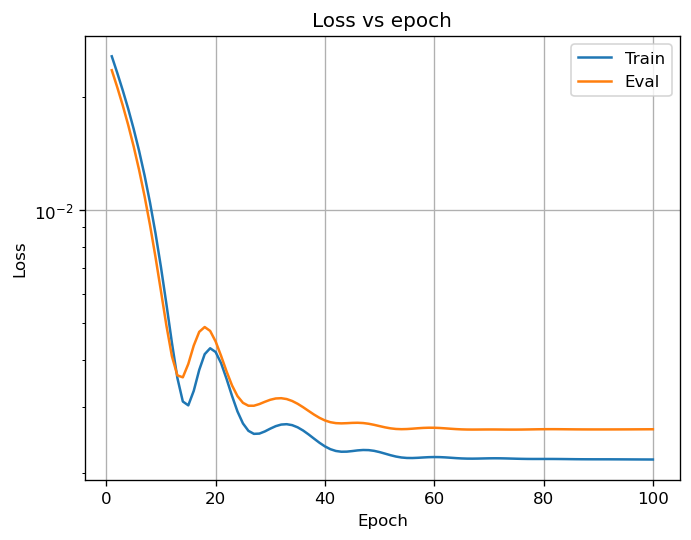

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_15783/3426932002.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


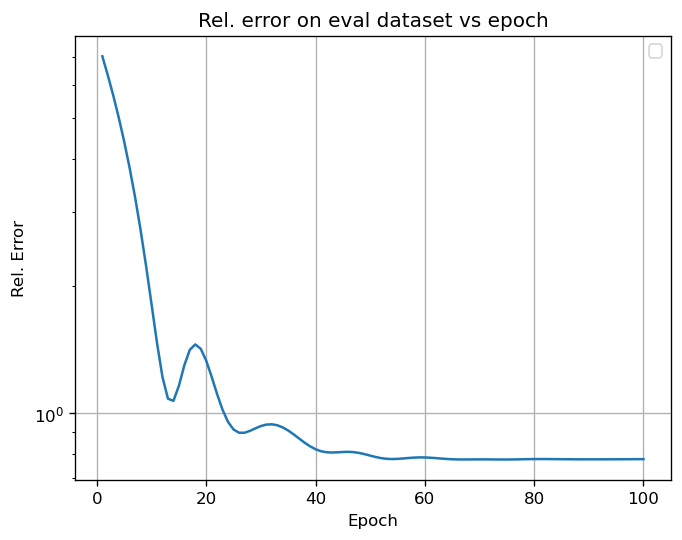

In [3]:
plt.figure(dpi = 120)
plt.title("Loss vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.semilogy(fno_trial.epochs, fno_trial.losses, label = "Train")
plt.semilogy(fno_trial.epochs, fno_trial.losses_eval, label = "Eval")
plt.legend()
plt.grid()
plt.show()

plt.figure(dpi = 120)
plt.title("Rel. error on eval dataset vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Rel. Error")
plt.semilogy(fno_trial.epochs, fno_trial.rel_errors_eval)
plt.legend()
plt.grid()
plt.show()

In [ ]:
# the VERY low standard variation across points tell me the model gives some kind of constant function. this is a major issues that needs fixing
# also, the model is very slow and its speed should be improved. to do: use real fft, avoid fft shift

# to try: sinusoidal embeddings (see literature), skip connections
# apply normalizations?
# to try: shceduler for learning rate

# better hyperparameter choices possible ? for sure


# Using FNO from neuralop.models (NeuralOperator library)

https://github.com/neuraloperator/neuraloperator

In [ ]:
from neuralop.models import FNO

FNO_neuralop = FNO(n_modes=(64, 64),
               hidden_channels=64,
               in_channels=2,
               out_channels=1)